# 📊 Bloque 2 — Sesión 2: Análisis de variables y relaciones

**Módulo:** Depuración, limpieza y Clasificación de Datos (5109)  
**Unidad Didáctica:** UD1 — Análisis exploratorio de datos  
**Duración estimada:** ~5 horas.

---

### Contenidos de esta sesión
- **2.3** Análisis de variables numéricas: estadísticos básicos, histogramas, boxplots
- **2.4** Análisis de variables categóricas: frecuencias absolutas y relativas, `value_counts`
- **2.5** Análisis de relaciones entre variables: correlación, scatter plots, heatmaps, pairplots

### Criterio de evaluación asociado
> **(CE c)** Se han identificado la estructura, variables y relaciones de los conjuntos de datos aplicando técnicas exploratorias.

In [1]:
# Librerías necesarias para esta sesión
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración de visualización
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['figure.dpi'] = 100

# Cargamos los datasets que usaremos en esta sesión
titanic  = sns.load_dataset('titanic')
penguins = sns.load_dataset('penguins').dropna()   # Eliminamos ausentes para esta sesión

print('✅ Librerías y datasets cargados correctamente')
print(f'   Titanic:  {titanic.shape}')
print(f'   Penguins: {penguins.shape}')

✅ Librerías y datasets cargados correctamente
   Titanic:  (891, 15)
   Penguins: (333, 7)


---
## 2.3 Análisis de variables numéricas

El análisis de variables numéricas busca responder:
- ¿Cuál es el valor central? (media, mediana)
- ¿Cuánta variabilidad hay? (desviación típica, rango intercuartílico)
- ¿Cómo se distribuyen los valores? (histograma)
- ¿Hay valores atípicos? (boxplot)

### Estadísticos principales

| Estadístico | Fórmula / Función | Qué mide |
|-------------|-------------------|----------|
| **Media** | `df[col].mean()` | Valor central (sensible a outliers) |
| **Mediana** | `df[col].median()` | Valor central robusto (percentil 50) |
| **Desv. típica** | `df[col].std()` | Dispersión respecto a la media |
| **Mínimo / Máximo** | `.min()` / `.max()` | Rango total de los datos |
| **Percentil 25 (Q1)** | `.quantile(0.25)` | 25% de los datos está por debajo |
| **Percentil 75 (Q3)** | `.quantile(0.75)` | 75% de los datos está por debajo |
| **IQR** | `Q3 - Q1` | Rango intercuartílico: dispersión robusta |

> 💡 Si **media > mediana**, la distribución tiene cola hacia la derecha (sesgo positivo). Si **media < mediana**, cola hacia la izquierda (sesgo negativo).

### 📌 Ejemplo 1 — Estadísticos básicos de variables numéricas

In [2]:
# Analizamos la columna 'fare' (precio del billete) del Titanic
fare = titanic['fare'].dropna()

q1  = fare.quantile(0.25)
q3  = fare.quantile(0.75)
iqr = q3 - q1

print('Estadísticos de la variable "fare" (precio del billete):')
print(f'  Conteo          : {fare.count()}')
print(f'  Media           : {fare.mean():.2f} £')
print(f'  Mediana (P50)   : {fare.median():.2f} £')
print(f'  Desv. típica    : {fare.std():.2f} £')
print(f'  Mínimo          : {fare.min():.2f} £')
print(f'  Percentil 25    : {q1:.2f} £')
print(f'  Percentil 75    : {q3:.2f} £')
print(f'  IQR (Q3 - Q1)   : {iqr:.2f} £')
print(f'  Máximo          : {fare.max():.2f} £')
print(f'\n💡 Media ({fare.mean():.1f}) >> Mediana ({fare.median():.1f}) → sesgo positivo fuerte')
print(f'   (hay pocos pasajeros con billetes muy caros que inflan la media)')

Estadísticos de la variable "fare" (precio del billete):
  Conteo          : 891
  Media           : 32.20 £
  Mediana (P50)   : 14.45 £
  Desv. típica    : 49.69 £
  Mínimo          : 0.00 £
  Percentil 25    : 7.91 £
  Percentil 75    : 31.00 £
  IQR (Q3 - Q1)   : 23.09 £
  Máximo          : 512.33 £

💡 Media (32.2) >> Mediana (14.5) → sesgo positivo fuerte
   (hay pocos pasajeros con billetes muy caros que inflan la media)


### 📌 Ejemplo 2 — Histograma: distribución de una variable numérica

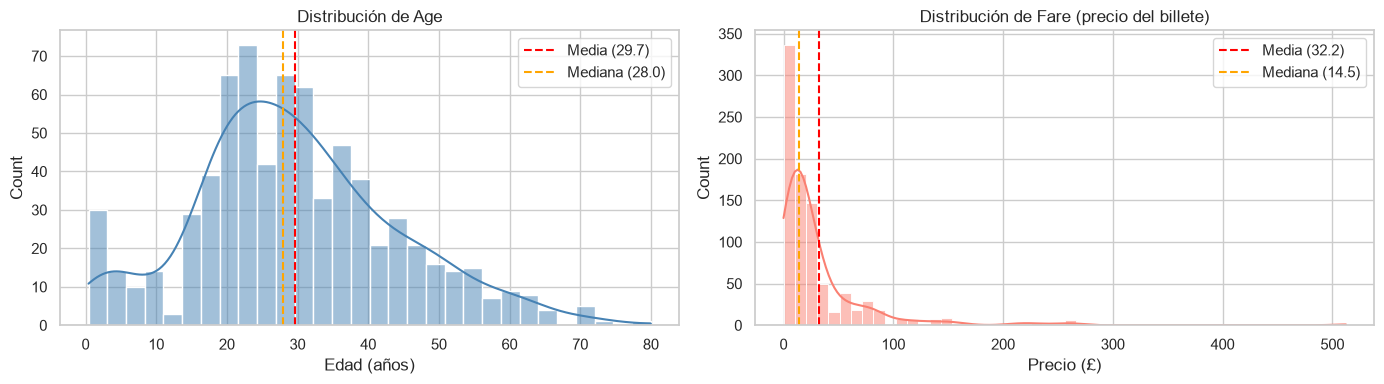

💡 "age" tiene distribución aproximadamente normal (media ≈ mediana).
   "fare" tiene cola muy larga a la derecha → transformación logarítmica útil en ML.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma de 'age'
sns.histplot(data=titanic, x='age', bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(titanic['age'].mean(),   color='red',    linestyle='--', label=f'Media ({titanic["age"].mean():.1f})')
axes[0].axvline(titanic['age'].median(), color='orange', linestyle='--', label=f'Mediana ({titanic["age"].median():.1f})')
axes[0].set_title('Distribución de Age')
axes[0].set_xlabel('Edad (años)')
axes[0].legend()

# Histograma de 'fare' — distribución muy sesgada
sns.histplot(data=titanic, x='fare', bins=50, kde=True, ax=axes[1], color='salmon')
axes[1].axvline(titanic['fare'].mean(),   color='red',    linestyle='--', label=f'Media ({titanic["fare"].mean():.1f})')
axes[1].axvline(titanic['fare'].median(), color='orange', linestyle='--', label=f'Mediana ({titanic["fare"].median():.1f})')
axes[1].set_title('Distribución de Fare (precio del billete)')
axes[1].set_xlabel('Precio (£)')
axes[1].legend()

plt.tight_layout()
plt.show()

print('💡 "age" tiene distribución aproximadamente normal (media ≈ mediana).')
print('   "fare" tiene cola muy larga a la derecha → transformación logarítmica útil en ML.')

### 📌 Ejemplo 3 — Boxplot: distribución y outliers

C:\Users\aas19\AppData\Local\Temp\ipykernel_7404\529727742.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=titanic, x='pclass', y='fare', ax=axes[1], palette='Set2')


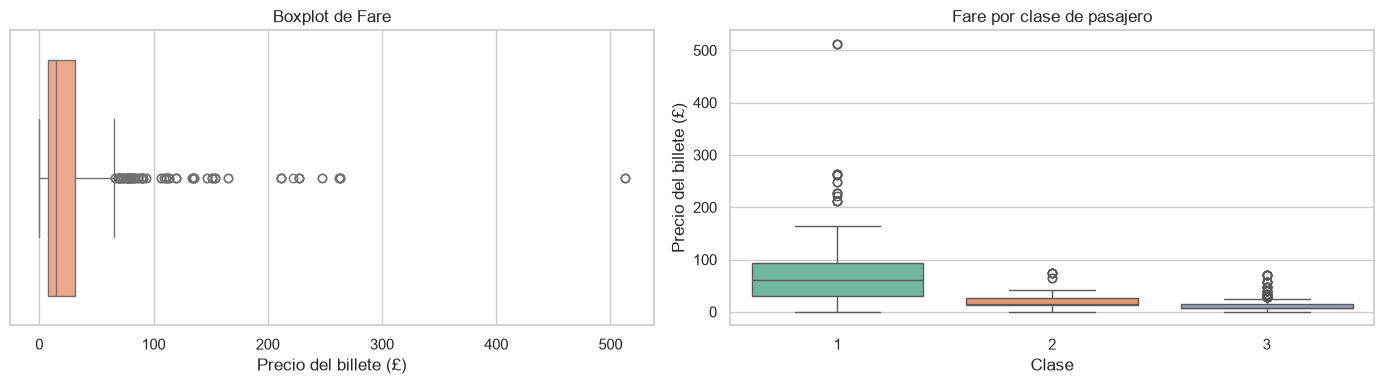

Anatomía del boxplot:
  ├─ Línea central = mediana (Q2)
  ├─ Borde inferior de la caja = Q1 (percentil 25)
  ├─ Borde superior de la caja = Q3 (percentil 75)
  ├─ Bigotes = hasta 1.5 × IQR desde la caja
  └─ Puntos fuera de bigotes = outliers potenciales


In [4]:
# El boxplot muestra Q1, mediana, Q3 y los bigotes (1.5 × IQR)
# Los puntos fuera de los bigotes son candidatos a outliers

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Boxplot simple de 'fare'
sns.boxplot(data=titanic, x='fare', ax=axes[0], color='lightsalmon')
axes[0].set_title('Boxplot de Fare')
axes[0].set_xlabel('Precio del billete (£)')

# Boxplot de 'fare' agrupado por clase
sns.boxplot(data=titanic, x='pclass', y='fare', ax=axes[1], palette='Set2')
axes[1].set_title('Fare por clase de pasajero')
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Precio del billete (£)')

plt.tight_layout()
plt.show()

print('Anatomía del boxplot:')
print('  ├─ Línea central = mediana (Q2)')
print('  ├─ Borde inferior de la caja = Q1 (percentil 25)')
print('  ├─ Borde superior de la caja = Q3 (percentil 75)')
print('  ├─ Bigotes = hasta 1.5 × IQR desde la caja')
print('  └─ Puntos fuera de bigotes = outliers potenciales')

In [5]:
# Detección de outliers con el criterio IQR
def detectar_outliers_iqr(serie):
    """Devuelve los outliers de una serie usando el criterio 1.5 × IQR."""
    q1  = serie.quantile(0.25)
    q3  = serie.quantile(0.75)
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    return serie[(serie < limite_inf) | (serie > limite_sup)]

outliers_fare = detectar_outliers_iqr(titanic['fare'].dropna())
outliers_age  = detectar_outliers_iqr(titanic['age'].dropna())

print(f'Outliers en "fare": {len(outliers_fare)} registros')
print(f'  Rango: {outliers_fare.min():.1f} — {outliers_fare.max():.1f} £')
print(f'\nOutliers en "age": {len(outliers_age)} registros')
print(f'  Valores: {sorted(outliers_age.unique())}')

Outliers en "fare": 116 registros
  Rango: 66.6 — 512.3 £

Outliers en "age": 11 registros
  Valores: [np.float64(65.0), np.float64(66.0), np.float64(70.0), np.float64(70.5), np.float64(71.0), np.float64(74.0), np.float64(80.0)]


---
## 2.4 Análisis de variables categóricas

Las variables categóricas no tienen estadísticos de posición como la media. Su análisis se basa en:
- **Frecuencias absolutas**: cuántas veces aparece cada categoría
- **Frecuencias relativas**: qué proporción del total representa cada categoría
- **Gráfico de barras**: visualización de las frecuencias

> ⚠️ Un desequilibrio grande en la variable objetivo (ej. 95% clase A / 5% clase B) puede hacer que un modelo aprenda a predecir siempre la clase mayoritaria y siga obteniendo alta precisión aunque no aprenda nada útil.

### 📌 Ejemplo 4 — Frecuencias absolutas y relativas

In [6]:
# Analizamos las variables categóricas del Titanic
categoricas = ['sex', 'pclass', 'embarked', 'who', 'class']

for col in categoricas:
    abs_freq = titanic[col].value_counts()
    rel_freq = titanic[col].value_counts(normalize=True).round(3)
    print(f'\n── {col} ──────────────────────────────')
    resumen = pd.DataFrame({'Absoluta': abs_freq, 'Relativa': rel_freq})
    print(resumen.to_string())


── sex ──────────────────────────────
        Absoluta  Relativa
sex                       
male         577     0.648
female       314     0.352

── pclass ──────────────────────────────
        Absoluta  Relativa
pclass                    
3            491     0.551
1            216     0.242
2            184     0.207

── embarked ──────────────────────────────
          Absoluta  Relativa
embarked                    
S              644     0.724
C              168     0.189
Q               77     0.087

── who ──────────────────────────────
       Absoluta  Relativa
who                      
man         537     0.603
woman       271     0.304
child        83     0.093

── class ──────────────────────────────
        Absoluta  Relativa
class                     
Third        491     0.551
First        216     0.242
Second       184     0.207


### 📌 Ejemplo 5 — Gráficos de barras para variables categóricas

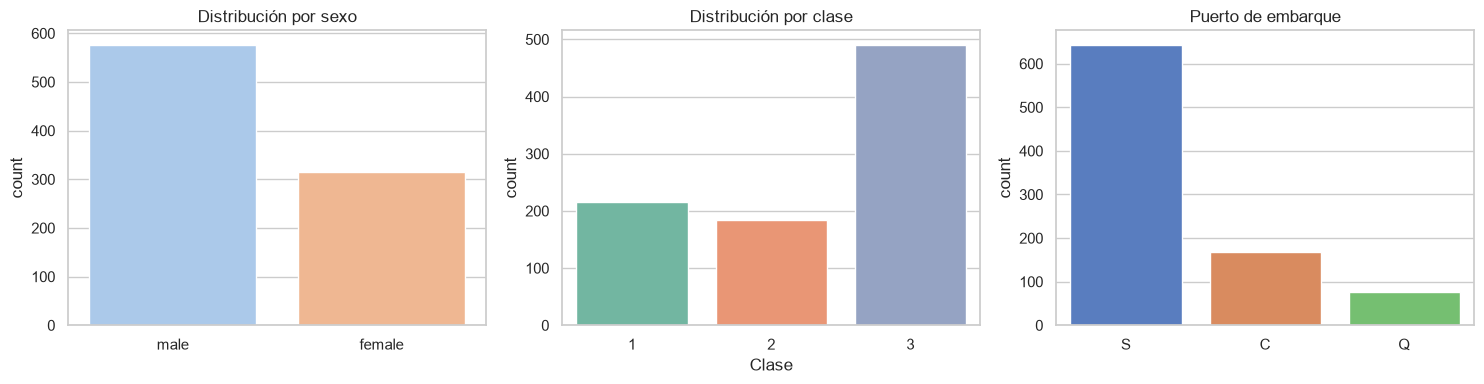

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribución por sexo
sns.countplot(data=titanic, x='sex', ax=axes[0], palette='pastel', hue='sex', legend=False)
axes[0].set_title('Distribución por sexo')
axes[0].set_xlabel('')

# Distribución por clase
sns.countplot(data=titanic, x='pclass', ax=axes[1], palette='Set2', hue='pclass', legend=False)
axes[1].set_title('Distribución por clase')
axes[1].set_xlabel('Clase')

# Distribución por puerto de embarque
sns.countplot(data=titanic, x='embarked', ax=axes[2], palette='muted', hue='embarked', legend=False)
axes[2].set_title('Puerto de embarque')
axes[2].set_xlabel('')

plt.tight_layout()
plt.show()

### 📌 Ejemplo 6 — Cruce de variable categórica con la variable objetivo

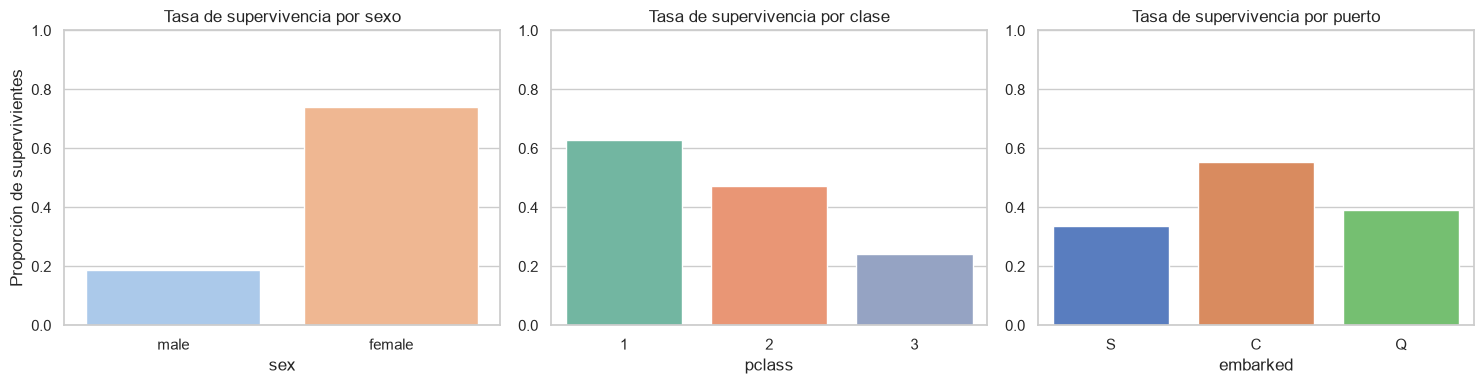

💡 Las mujeres sobrevivieron en mucho mayor proporción (75%) que los hombres (19%).
   Los pasajeros de 1ª clase sobrevivieron más que los de 3ª clase.
   → Estas variables tienen alta importancia predictiva para el modelo.


In [8]:
# Una de las preguntas clave del AED supervisado es:
# ¿cómo varía la variable objetivo según cada categoría?

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Supervivencia por sexo
sns.barplot(data=titanic, x='sex', y='survived', ax=axes[0],
            palette='pastel', hue='sex', legend=False, estimator='mean', errorbar=None)
axes[0].set_title('Tasa de supervivencia por sexo')
axes[0].set_ylabel('Proporción de supervivientes')
axes[0].set_ylim(0, 1)

# Supervivencia por clase
sns.barplot(data=titanic, x='pclass', y='survived', ax=axes[1],
            palette='Set2', hue='pclass', legend=False, estimator='mean', errorbar=None)
axes[1].set_title('Tasa de supervivencia por clase')
axes[1].set_ylabel('')
axes[1].set_ylim(0, 1)

# Supervivencia por puerto
sns.barplot(data=titanic, x='embarked', y='survived', ax=axes[2],
            palette='muted', hue='embarked', legend=False, estimator='mean', errorbar=None)
axes[2].set_title('Tasa de supervivencia por puerto')
axes[2].set_ylabel('')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print('💡 Las mujeres sobrevivieron en mucho mayor proporción (75%) que los hombres (19%).')
print('   Los pasajeros de 1ª clase sobrevivieron más que los de 3ª clase.')
print('   → Estas variables tienen alta importancia predictiva para el modelo.')

### 📌 Ejemplo 7 — Tabla de contingencia (crosstab)

Tasa de supervivencia por sexo y clase:
pclass     1     2     3
sex                     
female  0.97  0.92  0.50
male    0.37  0.16  0.14


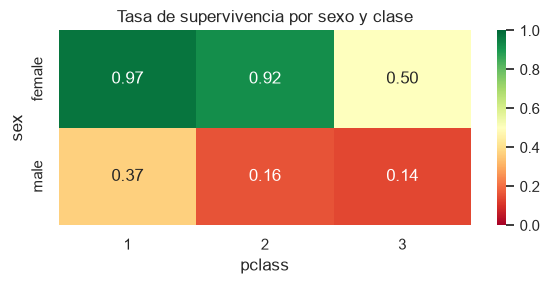


💡 Las mujeres de 1ª clase tuvieron una tasa de supervivencia del 97%.
   Los hombres de 3ª clase solo del 14%.


In [9]:
# La tabla de contingencia muestra la distribución conjunta de dos variables categóricas
tabla = pd.crosstab(
    index=titanic['sex'],
    columns=titanic['pclass'],
    values=titanic['survived'],
    aggfunc='mean'
).round(2)

print('Tasa de supervivencia por sexo y clase:')
print(tabla)

# Visualizamos como heatmap
fig, ax = plt.subplots(figsize=(6, 3))
sns.heatmap(tabla, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1, ax=ax)
ax.set_title('Tasa de supervivencia por sexo y clase')
plt.tight_layout()
plt.show()

print('\n💡 Las mujeres de 1ª clase tuvieron una tasa de supervivencia del 97%.')
print('   Los hombres de 3ª clase solo del 14%.')

---
### 🔧 Ejercicio 1 — Análisis de variables en el dataset Penguins

Usando el dataset `penguins`, analiza tanto las variables numéricas como las categóricas.

In [10]:
# TAREA 1: Muestra los estadísticos básicos (describe) de las variables numéricas de penguins
# print(penguins.describe().round(2))

# TAREA 2: ¿Qué variable numérica tiene mayor coeficiente de variación (std/mean)?
# Pista: calcula std/mean para cada columna numérica
# ...

# TAREA 3: Dibuja histogramas de las 4 variables numéricas (bill_length_mm, bill_depth_mm,
#           flipper_length_mm, body_mass_g), coloreando por especie
# Pista: usa sns.histplot con hue='species' en un grid de 2x2
# ...

# TAREA 4: Dibuja boxplots de 'body_mass_g' agrupados por sexo y por especie
# ...

# TAREA 5: ¿Cuántos pingüinos hay de cada especie? ¿Y de cada isla?
# print(penguins['species'].value_counts())
# print(penguins['island'].value_counts())

print('Completa las tareas comentadas arriba.')

Completa las tareas comentadas arriba.


---
## 2.5 Análisis de relaciones entre variables

Hasta ahora hemos analizado cada variable por separado (análisis univariado). El análisis de relaciones (bivariado o multivariado) busca detectar si las variables están relacionadas entre sí, y cómo.

| Relación | Herramientas |
|----------|--------------|
| Numérica vs. Numérica | Correlación de Pearson, diagrama de dispersión (scatter) |
| Numérica vs. Categórica | Boxplot agrupado, violinplot |
| Categórica vs. Categórica | Tabla de contingencia, heatmap |
| Todas vs. Todas | Pairplot, matriz de correlación (heatmap) |

### Correlación de Pearson

Mide la relación **lineal** entre dos variables numéricas. Varía entre -1 y 1:
- **r ≈ 1**: correlación positiva fuerte (cuando X sube, Y sube)
- **r ≈ -1**: correlación negativa fuerte (cuando X sube, Y baja)
- **r ≈ 0**: sin relación lineal (pero puede haber relación no lineal)

> ⚠️ **Correlación no implica causalidad.** Dos variables pueden estar correlacionadas sin que una cause la otra.

### 📌 Ejemplo 8 — Matriz de correlación

In [11]:
# Seleccionamos solo las columnas numéricas del dataset Penguins
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
corr = penguins[num_cols].corr(numeric_only=True).round(2)

print('Matriz de correlación de Pearson:')
print(corr)

Matriz de correlación de Pearson:
                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm               1.00          -0.23               0.65   
bill_depth_mm               -0.23           1.00              -0.58   
flipper_length_mm            0.65          -0.58               1.00   
body_mass_g                  0.59          -0.47               0.87   

                   body_mass_g  
bill_length_mm            0.59  
bill_depth_mm            -0.47  
flipper_length_mm         0.87  
body_mass_g               1.00  


### 📌 Ejemplo 9 — Heatmap de la matriz de correlación

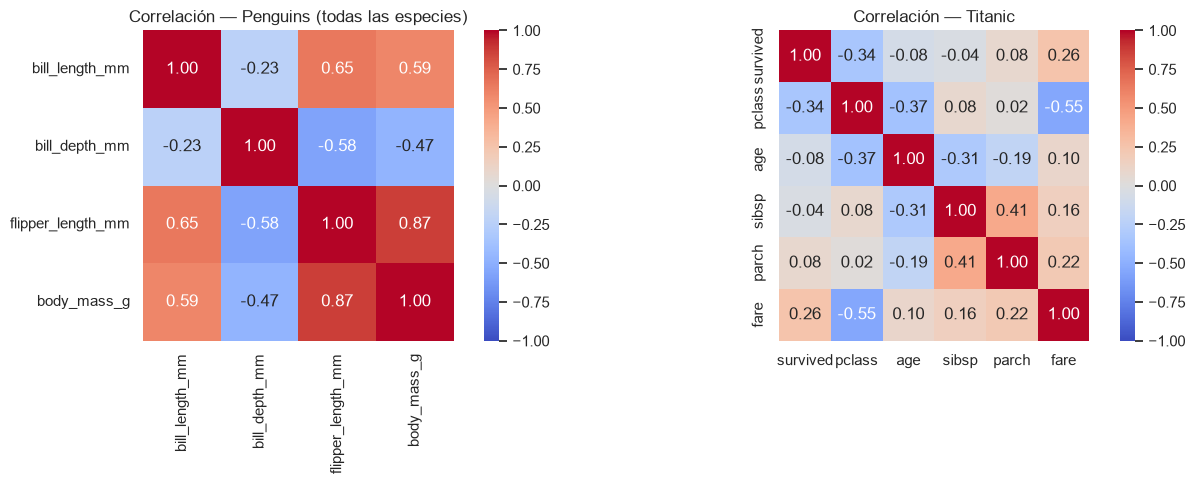

💡 En Penguins: flipper_length y body_mass tienen r = 0.87 → correlación muy alta.
   En Titanic: survived y pclass tienen r = -0.34 → más clase → menos supervivencia.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap — Penguins
corr_penguins = penguins[num_cols].corr()
mask = np.triu(np.ones_like(corr_penguins, dtype=bool), k=1)  # Ocultamos triángulo superior
sns.heatmap(
    corr_penguins, annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1,
    square=True, ax=axes[0]
)
axes[0].set_title('Correlación — Penguins (todas las especies)')

# Heatmap — Titanic (solo numéricas)
num_titanic = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
corr_titanic = titanic[num_titanic].corr()
sns.heatmap(
    corr_titanic, annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1,
    square=True, ax=axes[1]
)
axes[1].set_title('Correlación — Titanic')

plt.tight_layout()
plt.show()

print('💡 En Penguins: flipper_length y body_mass tienen r = 0.87 → correlación muy alta.')
print('   En Titanic: survived y pclass tienen r = -0.34 → más clase → menos supervivencia.')

### 📌 Ejemplo 10 — Diagrama de dispersión (scatter plot)

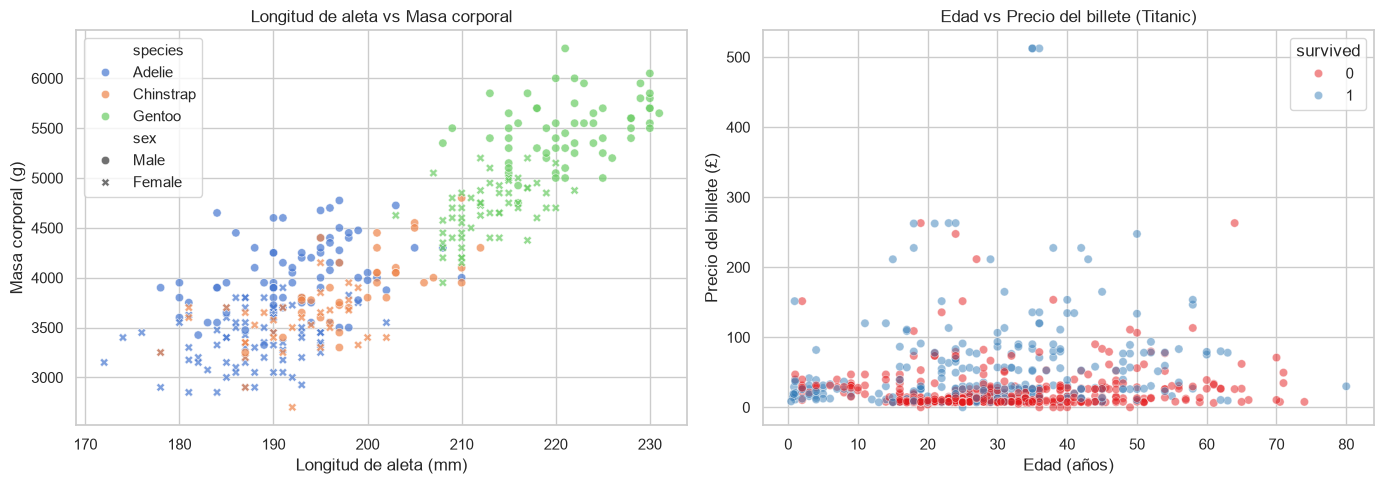

💡 En Penguins los tres clusters son visibles → las especies son linealmente separables.
   En Titanic los supervivientes tienden a tener billetes más caros.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: flipper_length vs body_mass, coloreado por especie
sns.scatterplot(
    data=penguins, x='flipper_length_mm', y='body_mass_g',
    hue='species', style='sex', alpha=0.7, ax=axes[0]
)
axes[0].set_title('Longitud de aleta vs Masa corporal')
axes[0].set_xlabel('Longitud de aleta (mm)')
axes[0].set_ylabel('Masa corporal (g)')

# Scatter: age vs fare (Titanic)
sns.scatterplot(
    data=titanic, x='age', y='fare',
    hue='survived', alpha=0.5, palette='Set1', ax=axes[1]
)
axes[1].set_title('Edad vs Precio del billete (Titanic)')
axes[1].set_xlabel('Edad (años)')
axes[1].set_ylabel('Precio del billete (£)')

plt.tight_layout()
plt.show()

print('💡 En Penguins los tres clusters son visibles → las especies son linealmente separables.')
print('   En Titanic los supervivientes tienden a tener billetes más caros.')

### 📌 Ejemplo 11 — Pairplot: todas las relaciones de una vez

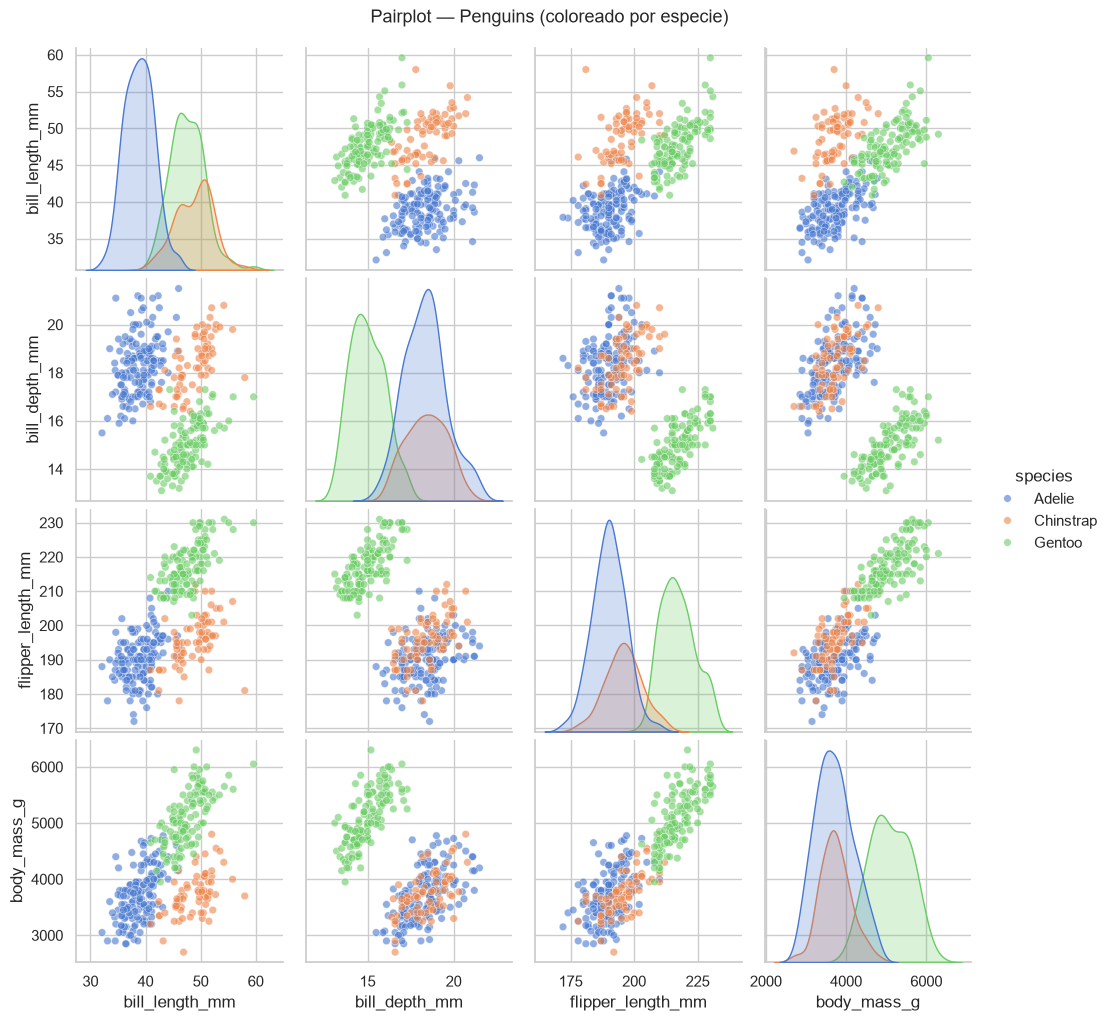

💡 El pairplot revela de un vistazo qué pares de variables separan mejor las especies.
   Observa cómo bill_depth vs bill_length tiene una relación invertida entre especies.


In [14]:
# El pairplot muestra la distribución de cada variable (diagonal)
# y la relación entre cada par de variables (fuera de la diagonal)
# Es ideal para una exploración rápida de datasets con pocas variables numéricas

g = sns.pairplot(
    penguins,
    vars=num_cols,
    hue='species',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 30}
)
g.figure.suptitle('Pairplot — Penguins (coloreado por especie)', y=1.02, fontsize=13)
plt.show()

print('💡 El pairplot revela de un vistazo qué pares de variables separan mejor las especies.')
print('   Observa cómo bill_depth vs bill_length tiene una relación invertida entre especies.')

### 📌 Ejemplo 12 — Relación numérica vs. categórica: violinplot

C:\Users\aas19\AppData\Local\Temp\ipykernel_7404\2831777782.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


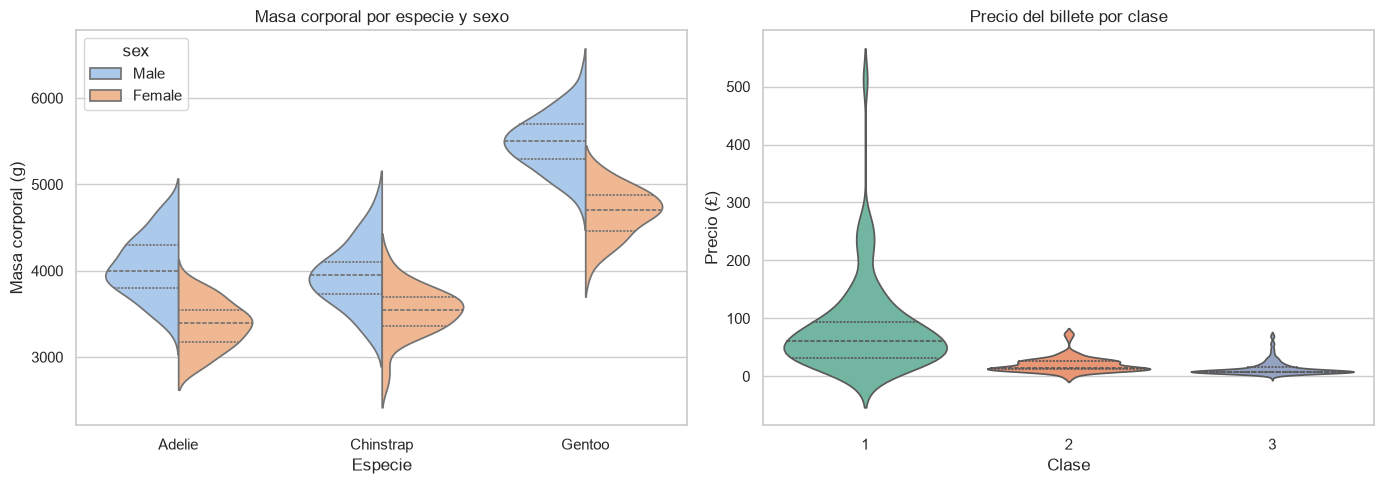

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Violinplot: combina boxplot + distribución de densidad
sns.violinplot(
    data=penguins, x='species', y='body_mass_g',
    hue='sex', split=True, inner='quart',
    palette='pastel', ax=axes[0]
)
axes[0].set_title('Masa corporal por especie y sexo')
axes[0].set_xlabel('Especie')
axes[0].set_ylabel('Masa corporal (g)')

# Violinplot: fare por clase en Titanic
sns.violinplot(
    data=titanic, x='pclass', y='fare',
    inner='quartile', palette='Set2', ax=axes[1]
)
axes[1].set_title('Precio del billete por clase')
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Precio (£)')

plt.tight_layout()
plt.show()

---
### 🔧 Ejercicio 2 — Análisis de relaciones en el dataset Diamonds

Usando el dataset `diamonds` de seaborn, analiza las relaciones entre variables.

In [16]:
diamonds = sns.load_dataset('diamonds')

# TAREA 1: Calcula la matriz de correlación de las variables numéricas
#           (carat, depth, table, price, x, y, z)
# cols_num = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']
# print(diamonds[cols_num].corr().round(2))

# TAREA 2: Dibuja el heatmap de esa matriz de correlación
# ...

# TAREA 3: ¿Qué variable numérica está más correlacionada con 'price'?
# Respuesta: ...

# TAREA 4: Dibuja un scatter plot de 'carat' vs 'price', coloreado por 'cut'
# ...

# TAREA 5: Dibuja un boxplot de 'price' agrupado por 'cut'
#           ¿Los diamantes de mejor calidad de corte ('Ideal') son más caros?
# ...

# TAREA 6: Dibuja una tabla de contingencia (crosstab) entre 'cut' y 'color'
#           ¿Existe alguna combinación dominante?
# ...

print('Completa las tareas comentadas arriba.')

Completa las tareas comentadas arriba.


---
### 🔧 Ejercicio 3 — AED completo de un dataset a elegir

Aplica todo lo aprendido en las sesiones 1 y 2 a un dataset de tu elección. Puedes usar uno de los disponibles en seaborn (`tips`, `car_crashes`, `mpg`, `exercise`) o cargar uno propio desde Kaggle o UCI.

In [17]:
# Carga tu dataset aquí
# df = sns.load_dataset('tips')   # Ejemplo con 'tips'

# BLOQUE 1 — INSPECCIÓN (sesión 1)
# - shape, dtypes, head, info, describe, nunique, value_counts
# - Mapa de valores ausentes

# BLOQUE 2 — VARIABLES NUMÉRICAS (esta sesión, apartado 2.3)
# - Estadísticos por columna numérica
# - Histogramas
# - Boxplots (con y sin agrupación)
# - Outliers con criterio IQR

# BLOQUE 3 — VARIABLES CATEGÓRICAS (esta sesión, apartado 2.4)
# - Frecuencias absolutas y relativas
# - Gráficos de barras
# - Cruce con la variable objetivo (si la hay)

# BLOQUE 4 — RELACIONES (esta sesión, apartado 2.5)
# - Matriz de correlación + heatmap
# - Scatter plots entre las variables más correlacionadas
# - Pairplot

# BLOQUE 5 — CONCLUSIONES
# Escribe aquí un breve resumen de tus hallazgos:
# - ¿Qué variables tienen mayor poder predictivo?
# - ¿Qué problemas de calidad has detectado?
# - ¿Qué pasos de preprocesado anticipas que serán necesarios?

print('Completa el AED completo del dataset elegido.')

Completa el AED completo del dataset elegido.


---
## 📝 Resumen de la sesión

| Concepto | Clave |
|----------|-------|
| Variables numéricas | Media, mediana, std, percentiles, IQR. Histograma para distribución, boxplot para outliers. |
| Sesgo | Media > mediana → cola derecha. Media < mediana → cola izquierda. |
| Outliers IQR | Valores fuera de `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]`. |
| Variables categóricas | `value_counts()` para frecuencias. Barplot para visualizar. Cruce con la variable objetivo. |
| Correlación de Pearson | r ∈ [-1, 1]. Solo mide relación lineal. No implica causalidad. |
| Heatmap de correlación | Visión global de todas las relaciones numéricas. |
| Scatter plot | Relación entre dos variables numéricas, con coloreado por categoría. |
| Pairplot | Distribuciones y relaciones de todas las variables numéricas de una vez. |

### 🔜 Próxima sesión
**Bloque 2 — Sesión 3:** Herramientas de visualización (matplotlib y seaborn en profundidad) y perfilado automático con ydata-profiling.